# 01_EDA — 探索的データ解析 (Exploratory Data Analysis)

このノートブックでは、生データを読み込み「**どんなデータなのか**」を把握します。
EDA はデータ分析の最初の関門で、ここを丁寧にやると後の前処理・モデリングがスムーズになります。

## EDA とは

> 「データの傾向や特徴を **可視化と統計量で確認する作業**」

よい機械学習モデルを作るには **特徴量エンジニアリング** (例: 月曜は特定商品が売れる → 曜日 × 商品をフラグ化) が必要で、
そのためには扱うデータを深く理解しておく必要があります。

## このノートブックで確認すること

| # | 観点 | 主な API |
|-|-|-|
| ① | **生データ (先頭/末尾)** | `df.head()`, `df.tail()` |
| ② | **行数・列数・列名** | `df.shape`, `df.columns` |
| ③ | **データの型と欠損値** | `df.info()`, `df.isnull().sum()` |
| ④ | **基本統計量** | `df.describe()` |
| ⑤ | **目的変数 vs 説明変数の相関** | `df.corr()`, `sns.heatmap` |
| ⑥ | **各変数の分布** | `df.hist()`, `sns.histplot` |
| ⑦ | **目的変数の特徴と異常値** | `df['Price'].hist()` |


In [1]:
# ===== プロジェクトの src/ を import できるようにする共通の準備 =====
# notebooks/ から見て1つ上の階層がプロジェクトルート (= data_analysis_project)
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /Users/kenta.hoji.ea/Desktop/pythonデータ分析/data_analysis_project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import japanize_matplotlib   # 日本語ラベルが必要なら
except ImportError:
    pass

from src import data_loader

%matplotlib inline
sns.set_theme(style='whitegrid')


## 1. データの読み込み

scikit-learn 内蔵のカリフォルニア住宅価格データセットを利用します。
初回はネットからダウンロードし、`data/raw/california_housing.csv` にキャッシュされます。


In [3]:
df = data_loader.load_raw()


### データの背景情報

このデータセットは **1990 年の米国国勢調査** から得られた、カリフォルニア州の住宅価格データ。

- 単位は **ブロックグループ** (1 ブロックあたり 600〜3000 人)
- レコード数: **20,640 件**
- 欠損値: なし
- 目的変数 `Price` は **住宅価格の中央値** (10 万ドル単位、最大 5.00001 で頭打ち処理)

### 各列の意味

| カラム名 | 意味 |
|-|-|
| `MedInc` | ブロックの所得中央値 |
| `HouseAge` | ブロックの家屋年齢の中央値 |
| `AveRooms` | 1 世帯あたりの平均居室数 |
| `AveBedrms` | 1 世帯あたりの平均寝室数 |
| `Population` | ブロックの人口 |
| `AveOccup` | 平均世帯人口 (= 人口 / 世帯数) |
| `Latitude` | 緯度 |
| `Longitude` | 経度 |
| **`Price`** | 住宅価格 (**目的変数**) |


## ① 生データを見る

まずは `head()` で先頭数行を表示します。
これだけで「列名」「単位」「だいたいの値域」 が頭に入ります。


In [4]:
df.head(10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [5]:
# 末尾も見ておくと「ファイル末尾に空行が混ざってないか」「欠損が偏ってないか」が分かる
df.tail(5)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


## ② 行数・列数・列名

In [6]:
print('shape:', df.shape)
print('行数:', df.shape[0])
print('列数:', df.shape[1])
print()
print('columns:')
print(df.columns.tolist())


shape: (20640, 9)
行数: 20640
列数: 9

columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Price']


## ③ データ型と欠損値

`info()` でデータ型と欠損数, `isnull().sum()` で列ごとの欠損数を確認します。

### 主要なデータ型

| dtype | 意味 |
|-|-|
| `int64` | 整数 |
| `float64` | 小数 |
| `object` | 文字列 (またはオブジェクト一般) |
| `bool` | 真偽値 |
| `datetime64[ns]` | 日時 |
| `category` | カテゴリ (省メモリ) |


In [7]:
print('--- dtypes ---')
print(df.dtypes)
print('\n--- info ---')
df.info()


--- dtypes ---
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Price         float64
dtype: object

--- info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
print('--- 欠損値の数 ---')
print(df.isnull().sum())
print('\n--- 欠損率 (%) ---')
print((df.isnull().mean() * 100).round(2))


--- 欠損値の数 ---
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

--- 欠損率 (%) ---
MedInc        0.0
HouseAge      0.0
AveRooms      0.0
AveBedrms     0.0
Population    0.0
AveOccup      0.0
Latitude      0.0
Longitude     0.0
Price         0.0
dtype: float64


**観察**: 今回のデータは欠損値ゼロでクリーン。
> 実務では欠損があるのが普通なので、ここで「どの列にどれくらい欠損があるか」を必ず確認する習慣をつけます。


## ④ 基本統計量

`describe()` は数値列ごとに代表的な統計量をまとめて返します。

### 各項目の意味

| 名前 | 意味 |
|-|-|
| `count` | 非欠損の要素数 |
| `mean` | 算術平均 |
| `std` | 標準偏差 (ばらつきの大きさ) |
| `min` / `max` | 最小値・最大値 |
| `25%` | 第1四分位数 (下位 25% 点) |
| `50%` | 中央値 (median) |
| `75%` | 第3四分位数 (上位 25% 点) |


In [9]:
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [10]:
# 数値列以外も含めたい場合は include='all'
df.describe(include='all')


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### 統計量から分かること (チェックリスト)

- `min < 0` のはずがない列に **負の値** が混じっていないか?
- `max` が極端に大きい/小さい → 外れ値 (outlier) の可能性
- `mean` と `50%` (中央値) が大きく違う → **歪んだ分布**
- `std` がゼロ → その列は **定数列** → モデル学習には使えない


In [11]:
# Price だけ詳しく見る
df['Price'].describe()


count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: Price, dtype: float64

**観察**:
- `Price` の最大値が `5.00001` でぴったり止まっている → 上限処理あり
- 平均 `2.07` に対して中央値 `1.80` → やや右に裾の長い分布


## ⑤ 相関係数とヒートマップ

### 相関係数とは

2 つの変数間の関係性の強さを `-1 〜 +1` で表す統計量。

| 相関係数 | 解釈 |
|-|-|
| `+1` に近い | 一方が増えると **他方も増える** (正の相関) |
| `0` 付近 | 関係が **薄い** |
| `-1` に近い | 一方が増えると **他方は減る** (負の相関) |

### corr() の引数 method

| 値 | 意味 |
|-|-|
| `'pearson'` (デフォルト) | ピアソンの積率相関 (線形関係) |
| `'spearman'` | スピアマンの順位相関 (単調関係) |
| `'kendall'` | ケンドールの順位相関 |


In [12]:
corr = df.corr()
corr


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site

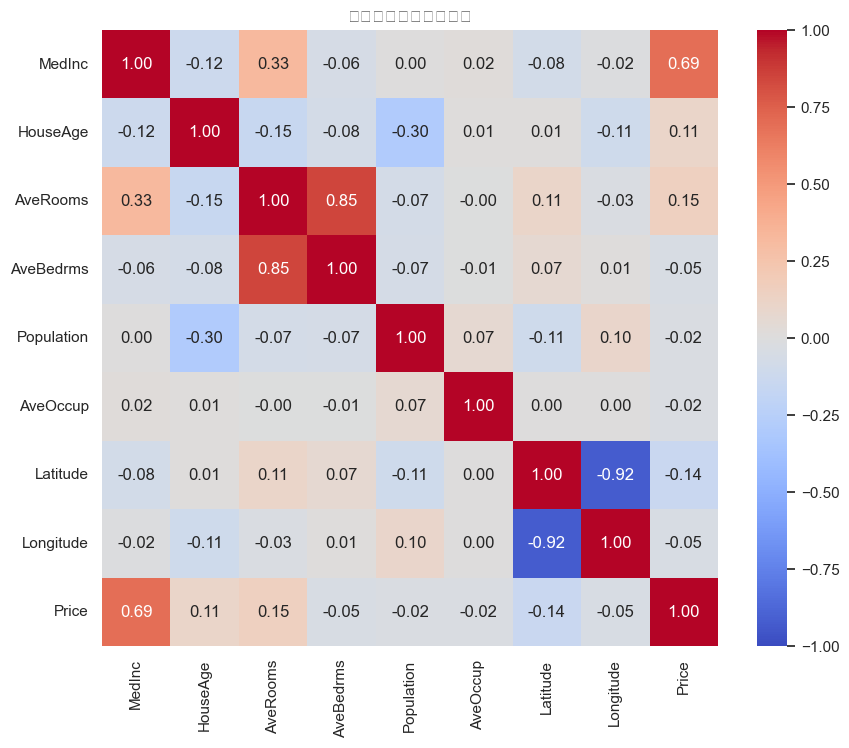

In [13]:
# ヒートマップで一望
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    square=True,
)
plt.title('相関係数ヒートマップ')
plt.show()


In [14]:
# Price との相関を強い順に並べる
corr_with_price = corr['Price'].drop('Price').sort_values(ascending=False)
print('Price との相関 (絶対値の大きい順):')
print(corr_with_price)


Price との相関 (絶対値の大きい順):
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64


**観察**:
- `MedInc` (所得中央値) と `Price` が **+0.69** の正の相関 → 「収入が高いほど良い家に住む」傾向と合致
- `Latitude` と `Longitude` は当然 -1 に近い (地理的に直交した軸ではない)
- `AveRooms` と `AveBedrms` も強い相関 → 多重共線性に注意


## ⑥ 各変数の分布

ヒストグラムで形 (正規分布っぽいか, 歪んでいるか, 多峰か) を確認。


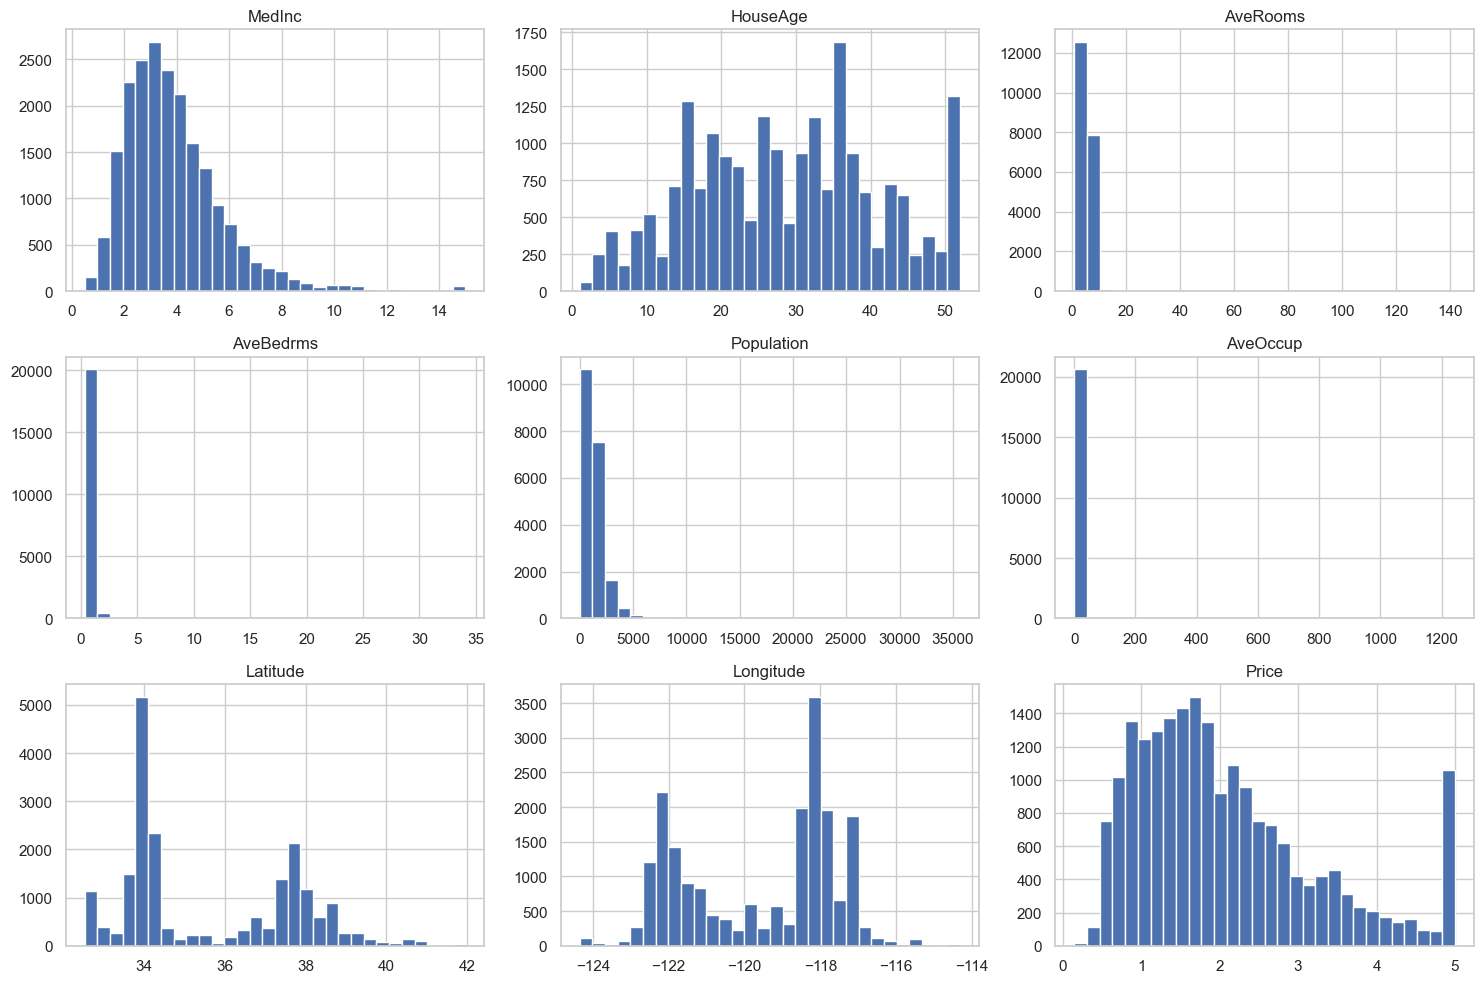

In [15]:
df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


### 分布の形から分かること

| 形状 | 解釈・対処 |
|-|-|
| 正規分布っぽい | 標準化との相性が良い |
| 右に裾を引く | 対数変換 (log) を検討 |
| 左に裾を引く | 反転して log を検討 |
| 2 つの山 (二峰) | データに 2 グループ混在の可能性 |
| 極端な飛び値 | 外れ値・上限処理を疑う |


## ⑦ 目的変数 `Price` の詳細

最大値付近に異常に多いデータがある (上限処理) ことに気づきましょう。
これは後の **後処理 (クリッピング)** のヒントになります。


/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-package

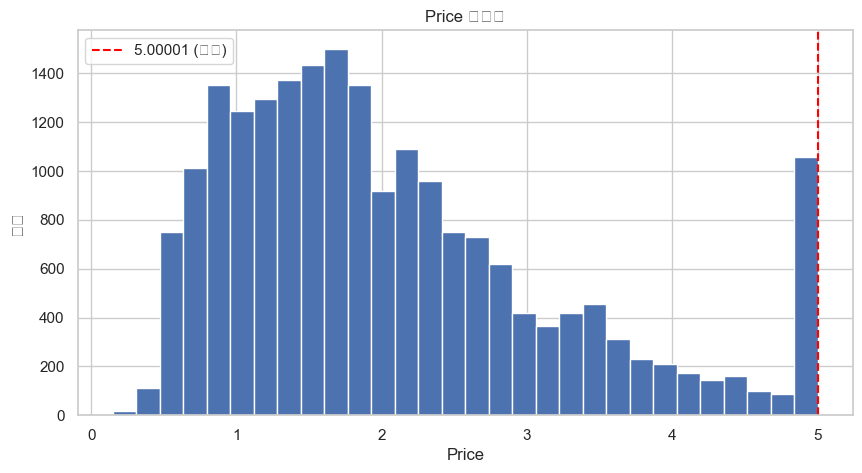

In [16]:
df['Price'].hist(bins=30, figsize=(10, 5))
plt.title('Price の分布')
plt.xlabel('Price')
plt.ylabel('度数')
plt.axvline(5.00001, color='red', linestyle='--', label='5.00001 (上限)')
plt.legend()
plt.show()


In [17]:
# 上限ぴったりのレコード数を確認
print(f"Price == 5.00001 のレコード数: {(df['Price'] == 5.00001).sum()}")
print(f"全体に占める割合: {(df['Price'] == 5.00001).mean() * 100:.2f}%")


Price == 5.00001 のレコード数: 965
全体に占める割合: 4.68%


**観察**:
- `5.00001` ちょうどのレコードが **965 件** (約 4.7%) もある
- これは「**国勢調査で上限が処理されたデータ**」と考えられる
- → モデル予測時に 5.00001 を超える値は **5.00001 にクリップ** すれば精度が改善する見込み


## ⑧ 散布図で関係性を見る

最も相関の強かった `MedInc` と `Price` の散布図を見ます。


/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25152 (\N{CJK UNIFIED IDEOGRAPH-6240}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22830 (\N{CJK UNIFIED IDEOGRAPH-592E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site

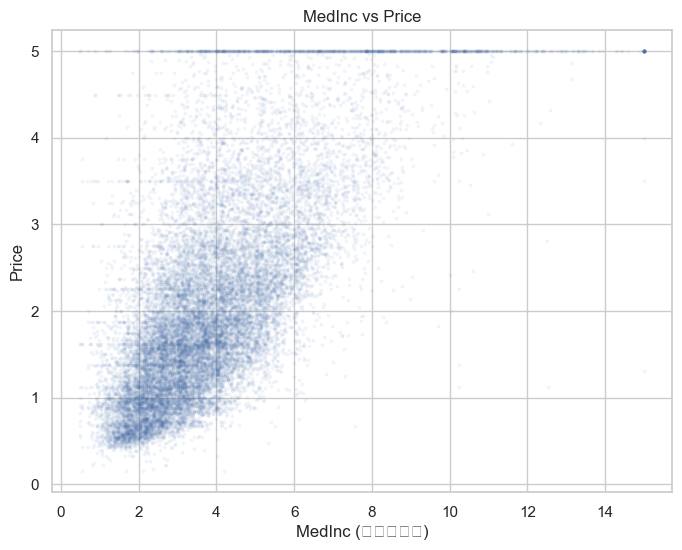

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(df['MedInc'], df['Price'], alpha=0.05, s=3)
plt.title('MedInc vs Price')
plt.xlabel('MedInc (所得中央値)')
plt.ylabel('Price')
plt.show()


**観察**: 確かに右上がりの正の相関が見えます。
上端 `5.00001` のところに横一文字に並ぶデータがあり、上限処理の存在が再確認できます。


## ⑨ 緯度経度で地理的に見てみる

緯度経度があるデータは地図的にプロットすると新しい発見があります。


/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-package

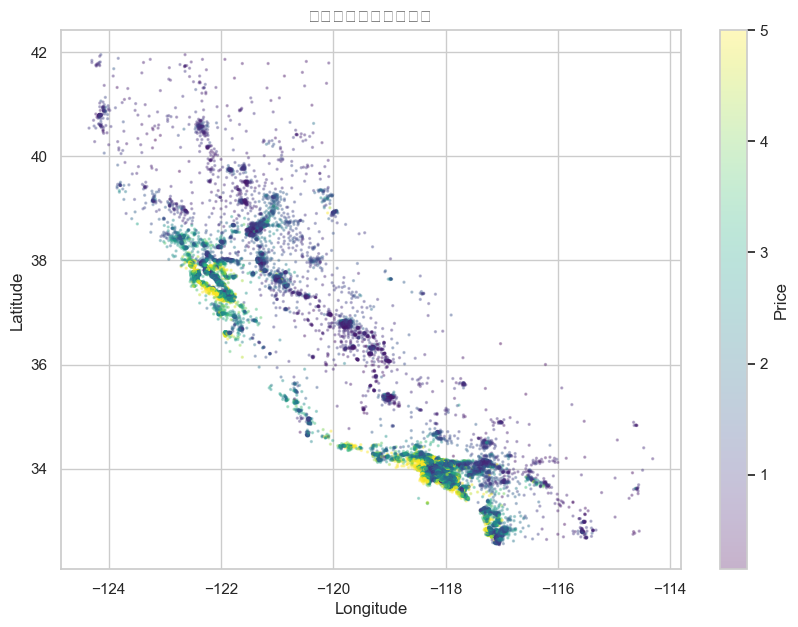

In [19]:
plt.figure(figsize=(10, 7))
sc = plt.scatter(df['Longitude'], df['Latitude'],
                 c=df['Price'], cmap='viridis',
                 alpha=0.3, s=2)
plt.colorbar(sc, label='Price')
plt.title('地理的な住宅価格分布')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


**観察**: 海岸線沿い (左下のサンディエゴ、左上のサンフランシスコ周辺) の住宅価格が高い。
→ 緯度経度を組み合わせた「海岸からの距離」のような特徴量を作れる可能性。


## ⑩ 箱ひげ図 (外れ値の可視化)

`AveOccup` (平均世帯人口) の分布を箱ひげ図で見てみます。


/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31665 (\N{CJK UNIFIED IDEOGRAPH-7BB1}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12402 (\N{HIRAGANA LETTER HI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12370 (\N{HIRAGANA LETTER GE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/p

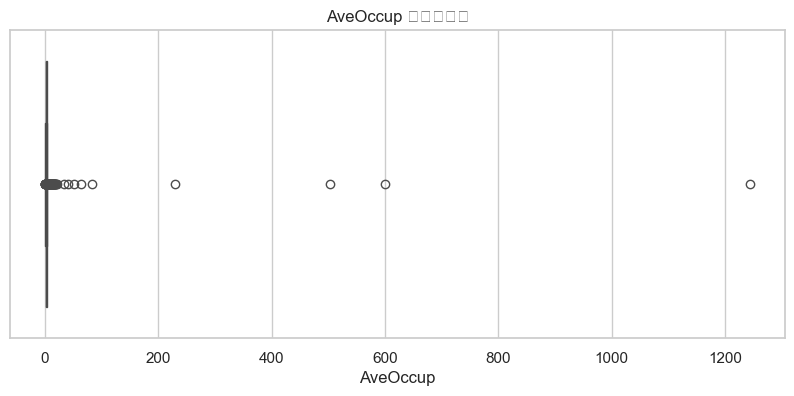

In [20]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['AveOccup'])
plt.title('AveOccup の箱ひげ図')
plt.show()


In [21]:
# 1000 以上の極端な値の件数 (見間違いではないか確認)
print(f"AveOccup > 100 のレコード数: {(df['AveOccup'] > 100).sum()}")
print('該当行:')
df[df['AveOccup'] > 100].head()


AveOccup > 100 のレコード数: 4
該当行:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51,0.675
13034,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15,2.250
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70,3.500
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,1.375


**観察**: `AveOccup` (平均世帯人口) に **数百〜千** の異常値が存在。
明らかにデータ入力ミスか、特殊な施設 (寮など) の可能性があります。
→ 前処理で外れ値の扱いを検討する必要があります。


## EDA で得た気づきまとめ

| # | 気づき | 後段への影響 |
|-|-|-|
| 1 | 欠損なし | 欠損値処理は不要 |
| 2 | `MedInc` と `Price` の相関が強い (+0.69) | 重要な特徴量 |
| 3 | `Price` が 5.00001 で上限処理 (約 4.7%) | 予測値もクリッピングする後処理を入れる |
| 4 | `AveOccup` に極端な外れ値あり | 外れ値処理を検討 |
| 5 | `Population` と `AveOccup` がある | 世帯数を求める特徴量生成が可能 |
| 6 | 緯度経度がある | 地理的な特徴量を作れる可能性 |

次は `02_preprocessing.ipynb` で **前処理と特徴量生成** を行います。
